In [ ]:
# create a seaborn boxplot
# compare salary_year_avg
# filter Dataframe by job_title_short == ['Data Analyst', 'Data Engineer', 'Data Scientist']
# filter Dataframe by job_country == India
# remove (dropna) for salary_year_avg
# xlim(0, 300,000) formatted as '$---k' integer
# title = 'Yearly Salary Comparison for Data Roles in India'
# xlabel(Yearly Salary ($USD))

In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [ ]:


# xlim(0, 300,000) formatted as '$---k' integer


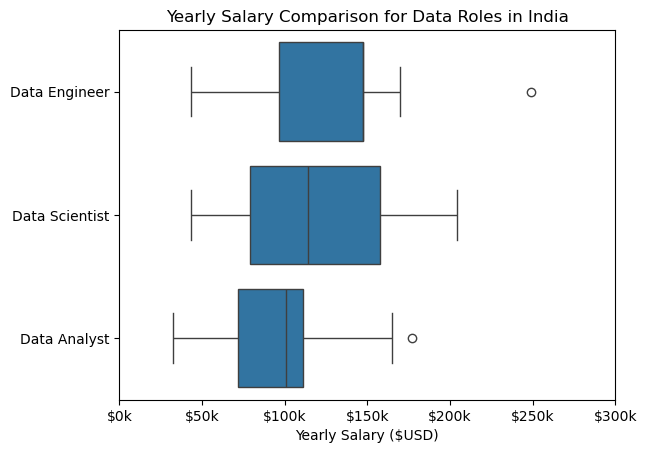

In [10]:
titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_IN = df[df['job_country'] == 'India'].copy()
df_IN = df_IN.dropna(subset=['salary_year_avg'])
df_IN_filtered = df_IN[df_IN['job_title_short'].isin(titles)]

sns.boxplot(data=df_IN_filtered, x='salary_year_avg', y='job_title_short')
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.ylabel('')
plt.xlabel('Yearly Salary ($USD)')
plt.xlim(0, 300000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.show()

In [11]:
df_IN_filtered.groupby('job_title_short')['salary_year_avg'].describe()

,count,mean,std,min,25%,50%,75%,max
job_title_short,,,,,,,,
Data Analyst,94.0,99149.925532,64297.459680,32400.0,71700.0,100500.0,111175.0,650000.0
Data Engineer,169.0,123312.390533,33914.612191,43200.0,96773.0,147500.0,147500.0,249000.0
Data Scientist,92.0,118203.690217,41258.733259,43200.0,79200.0,114008.0,157500.0,204381.0


In [ ]:



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [ ]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()
df_DS_US = df_DS_US.dropna(subset=['salary_year_avg'])

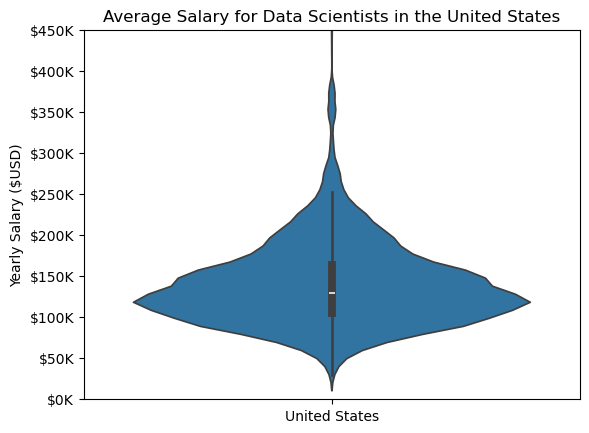

In [24]:
sns.violinplot(x='job_country', y='salary_year_avg', data=df_DS_US)
plt.title('Average Salary for Data Scientists in the United States')
plt.xlabel('')
plt.ylabel('Yearly Salary ($USD)')
plt.ylim(0, 450000)

# use custom formatting for the salary axis == and plt.gca().yaxis.set_major_formatter()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()